Daily Challenge : Comprehensive Mobile Price Analysis
===
Project Tasks:

1. **Data Loading and Exploration:**

Utilize Pandas to load the dataset and explore its initial structure.
Summarize features, target variable, and their respective data types.
Conduct basic descriptive statistics for an overview of the dataset.


2. **Data Cleaning and Preprocessing:**

Address missing or null values.
Transform categorical data into numerical format using suitable methods.


3. **Statistical Analysis with NumPy and SciPy:**

Execute detailed statistical analysis on each feature, including:
Calculation of central tendency measures (mean, median, mode).
Analysis of variability (range, variance, standard deviation).
Evaluation of distribution shapes through skewness and kurtosis.
Perform hypothesis testing for statistical significance between groups (e.g., different price ranges).
Investigate feature-target correlations using SciPy.
Apply advanced SciPy statistical functions for deeper insights.


4. **Data Visualization with Matplotlib:**

Produce histograms, scatter plots, and box plots for data distribution and relationship insights.
Employ heatmaps for correlation visualization.
Ensure clarity in plots with appropriate titles, labels, and axis information.


5. **Insight Synthesis and Conclusion:**

Derive conclusions from statistical tests and visualizations.
Identify key determinants in mobile price classification.
Highlight any unexpected or significant findings.


**Data Loading and exploration:**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('train.csv')

In [4]:
print('---- Data info ----')
print(df.info())


---- Data info ----
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18 

In [4]:
print(df.head())

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

In [9]:
print(df.tail())

      battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  \
1995            794     1          0.5         1   0       1           2   
1996           1965     1          2.6         1   0       0          39   
1997           1911     0          0.9         1   1       1          36   
1998           1512     0          0.9         0   4       1          46   
1999            510     1          2.0         1   5       1          45   

      m_dep  mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  \
1995    0.8        106        6  ...       1222      1890   668    13     4   
1996    0.2        187        4  ...        915      1965  2032    11    10   
1997    0.7        108        8  ...        868      1632  3057     9     1   
1998    0.1        145        5  ...        336       670   869    18    10   
1999    0.9        168        6  ...        483       754  3919    19     4   

      talk_time  three_g  touch_screen  wifi  price_range  
1995    

In [6]:
print(df.describe())

       battery_power       blue  clock_speed     dual_sim           fc  \
count    2000.000000  2000.0000  2000.000000  2000.000000  2000.000000   
mean     1238.518500     0.4950     1.522250     0.509500     4.309500   
std       439.418206     0.5001     0.816004     0.500035     4.341444   
min       501.000000     0.0000     0.500000     0.000000     0.000000   
25%       851.750000     0.0000     0.700000     0.000000     1.000000   
50%      1226.000000     0.0000     1.500000     1.000000     3.000000   
75%      1615.250000     1.0000     2.200000     1.000000     7.000000   
max      1998.000000     1.0000     3.000000     1.000000    19.000000   

            four_g   int_memory        m_dep    mobile_wt      n_cores  ...  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000  ...   
mean      0.521500    32.046500     0.501750   140.249000     4.520500  ...   
std       0.499662    18.145715     0.288416    35.399655     2.287837  ...   
min       0.00000

In [8]:
print(df.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='str')


**Data Cleaning and Preprocessing:**

In [5]:
missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

categorical_cols = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Missing values per column:
 battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64
blue: [0 1]
dual_sim: [0 1]
four_g: [0 1]
three_g: [0 1]
touch_screen: [0 1]
wifi: [1 0]


**Statistical Analysis:**


In [6]:
stats_summary = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Mode': df.mode().iloc[0],
    'Std Dev': df.std(),
    'Skewness': df.skew(),
    'Kurtosis': df.kurtosis()
})
print(stats_summary)

groups = [df[df['price_range'] == i]['ram'] for i in range(4)]
f_stat, p_val = stats.f_oneway(*groups)
print(f"\nANOVA for RAM across Price Ranges: F-stat={f_stat:.2f}, p-value={p_val:.4e}")

correlations = df.corr()['price_range'].sort_values(ascending=False)
print("\nCorrelations with Price Range:\n", correlations)

                     Mean  Median    Mode      Std Dev  Skewness  Kurtosis
battery_power  1238.51850  1226.0   618.0   439.418206  0.031898 -1.224144
blue              0.49500     0.0     0.0     0.500100  0.020016 -2.001602
clock_speed       1.52225     1.5     0.5     0.816004  0.178084 -1.323417
dual_sim          0.50950     1.0     1.0     0.500035 -0.038035 -2.000555
fc                4.30950     3.0     0.0     4.341444  1.019811  0.277076
four_g            0.52150     1.0     1.0     0.499662 -0.086144 -1.994575
int_memory       32.04650    32.0    27.0    18.145715  0.057889 -1.216074
m_dep             0.50175     0.5     0.1     0.288416  0.089082 -1.274349
mobile_wt       140.24900   141.0   182.0    35.399655  0.006558 -1.210376
n_cores           4.52050     4.0     4.0     2.287837  0.003628 -1.229750
pc                9.91650    10.0    10.0     6.064315  0.017306 -1.171499
px_height       645.10800   564.0   347.0   443.780811  0.666271 -0.315865
px_width       1251.51550

RAM is the dominant factor: It shows a massive correlation ($0.917$) with the price range.

Statistical Significance: The ANOVA test for RAM yielded a $p$-value of $0.0$, indicating that the differences in RAM between price groups are statistically significant and not due to chance.

Distribution: Most features like battery_power and ram have low skewness, indicating relatively symmetric distributions, though three_g is highly skewed since most phones in the dataset support it.

**Data Visualization:**

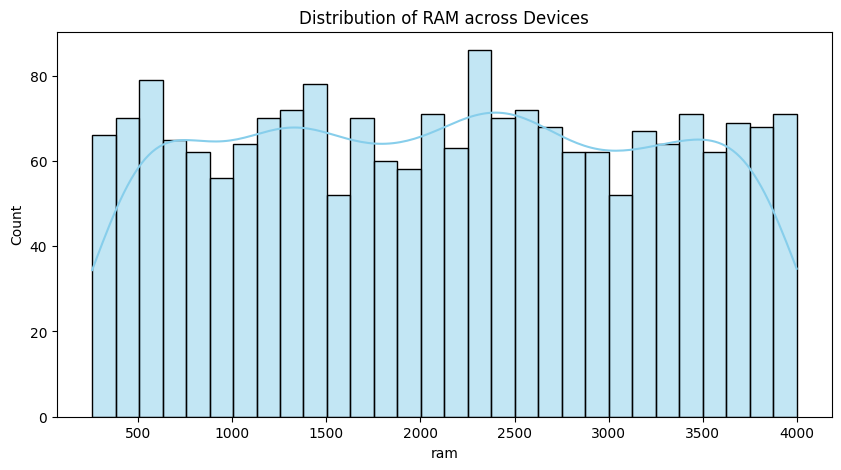

/var/folders/11/01wml45d32l3bgdl2z4gyjth0000gn/T/ipykernel_5042/1340059742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_range', y='ram', data=df, palette='Set2')


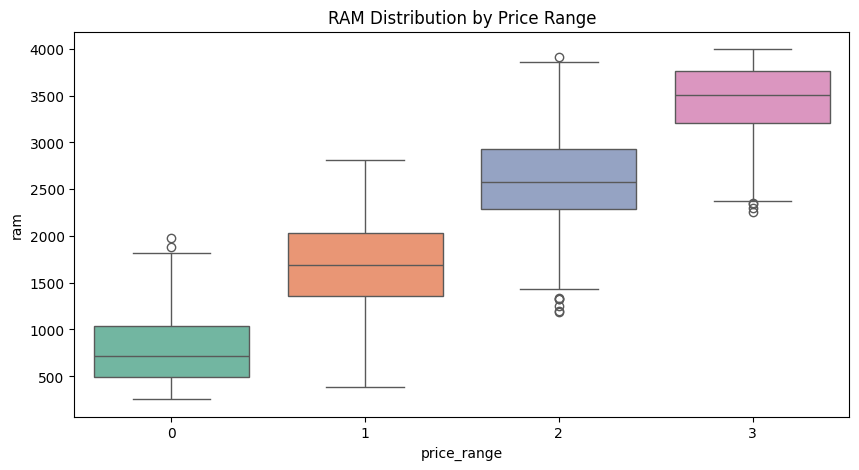

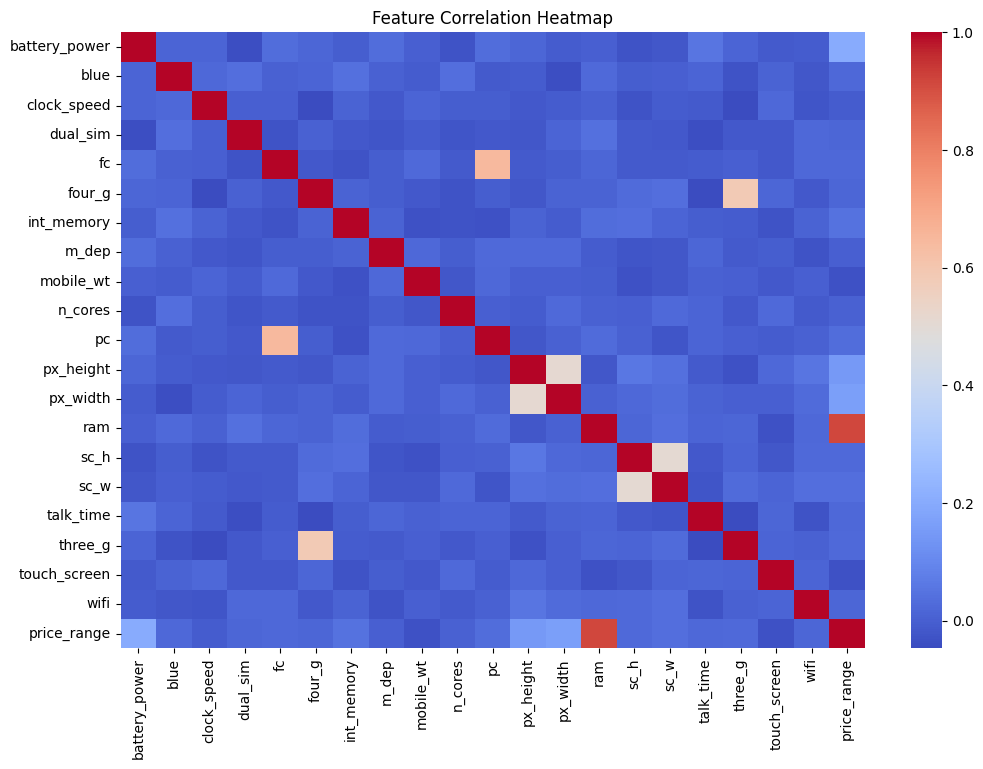

In [10]:
# RAM
plt.figure(figsize=(10, 5))
sns.histplot(df['ram'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of RAM across Devices')
plt.show()

# RAM vs Price Range
plt.figure(figsize=(10, 5))
sns.boxplot(x='price_range', y='ram', data=df, palette='Set2')
plt.title('RAM Distribution by Price Range')
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

The box plot clearly illustrates that as the price_range increases, the ram capacity increases linearly with almost no overlap between the 75th percentile of one category and the 25th of the next. The heatmap reinforces this, showing that while features like battery_power and pixel dimensions (px_height, px_width) have a positive relationship with price, ram is the only feature with a nearly perfect linear correlation.

Key Determinant: RAM is the single most important hardware specification for determining the price range of a mobile phone. A higher RAM capacity is almost always associated with a higher price category.

Secondary Factors: Battery Power and Screen Resolution (pixel width and height) also play significant roles, though their influence is much smaller compared to RAM.

Insignificant Features: Features like clock_speed, mobile_wt (weight), and touch_screen have very low or even slightly negative correlations with price, suggesting they are standard features that do not vary drastically across price tiers.

Conclusion: 

Manufacturers primarily differentiate mobile phone tiers through memory capacity and battery life. If you were to build a predictive model, focusing on RAM, battery, and screen resolution would yield the highest accuracy.